In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2
from scipy.stats import lognorm
from scipy.optimize import least_squares

### Import results
- Import questionnaire results and convert to lists
- Create list of realizations with true answers to calibration questions

In [7]:
res = pd.read_excel('Resultaten.xlsx')
for i in range(len(res)):
    txt = f"res_{i+1} = np.array([res.iloc[{i}, 0:10].values])[0]"
    exec(txt)
    txt2 = f"expert_{i+1} = [[float(val.replace(' ', '')) for val in item.split(',') if val.strip()] for item in res_{i+1}]"
    exec(txt2)
    txt3 = f"int_{i+1} = np.array([res.iloc[{i}, 10:14].values])[0]"
    exec(txt3)
    txt4 = f"expert_int_{i+1} = [[float(val.replace(' ', '')) for val in item.split(',') if val.strip()] for item in int_{i+1}]"
    exec(txt4)
realization = [200, 7*10**6, 5*10**6, 101552, 121, 3.57, 112, 10.6*10**6, 43*10**6, 530000]

In [8]:
expert_data = [expert_1, expert_2, expert_3, expert_4, expert_5, expert_6, expert_7, expert_8, expert_9]
expert_int = [expert_int_1, expert_int_2, expert_int_3, expert_int_4, expert_int_5, expert_int_6, expert_int_7, expert_int_8, expert_int_9]

### Plot results
Plot results for calibration questions

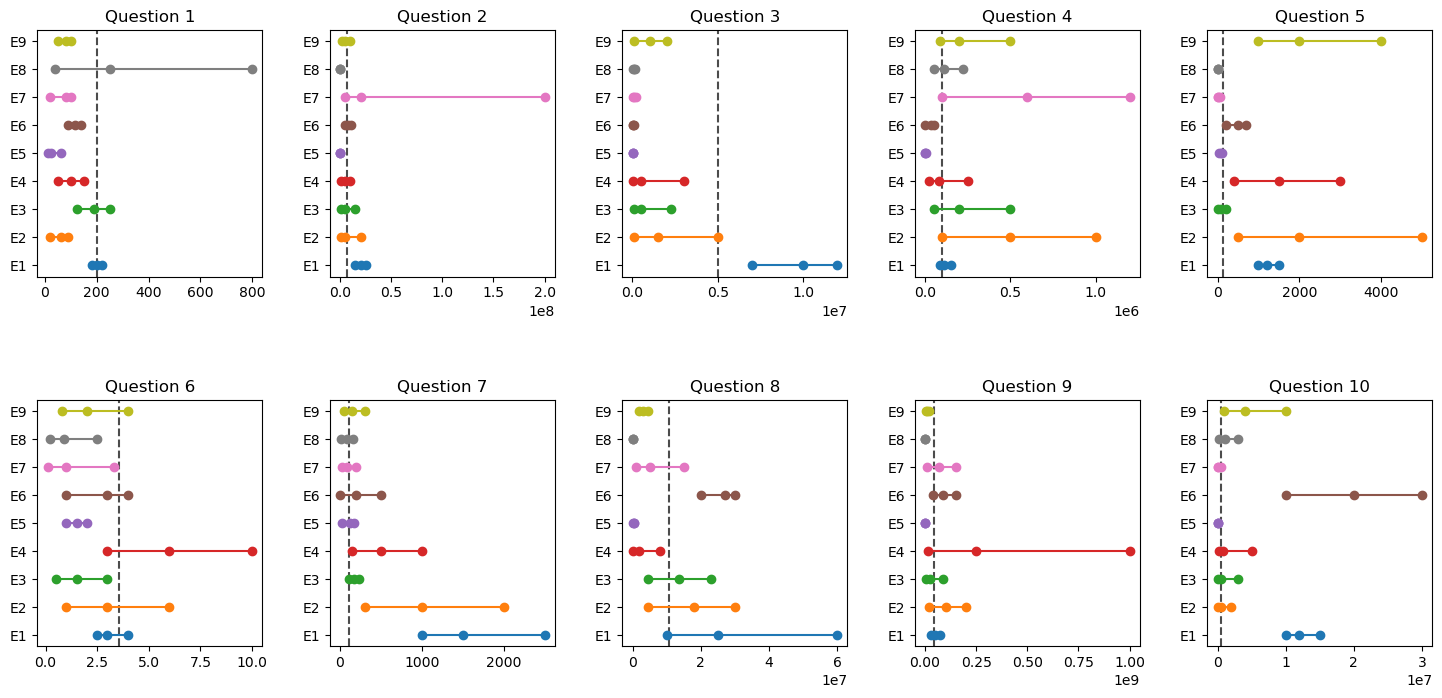

In [9]:
plt.figure(figsize=(18, 8))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for i in range(len(realization)):
    ax = plt.subplot(2, 5, i + 1)

    ax.axvline(realization[i], color='k', linestyle='--', label='Realization', alpha=0.7)
    
    for x, expert_answers in enumerate(expert_data):
        y_value = x + 1
        ax.plot(expert_answers[i], [y_value] * 3, 'o-', label=f'Expert {x+1}')
    
    ax.set_yticks(range(1, len(expert_data) + 1))
    ax.set_yticklabels([f'E{j+1}' for j in range(len(expert_data))])
    ax.set_title(f'Question {i + 1}')

plt.show()

### Determine calibration score
- Define functions for determining S vector and calibration score
- Apply functions to results

In [10]:
def S_vector(realization, Expert):
    Expert = np.array(Expert)
    realization = np.array(realization)
    
    s_empty = np.zeros(4)
    
    s_empty[0] = np.sum(realization <= Expert[:, 0])
    s_empty[1] = np.sum((Expert[:, 0] < realization) & (realization <= Expert[:, 1]))
    s_empty[2] = np.sum((Expert[:, 1] < realization) & (realization <= Expert[:, 2]))
    s_empty[3] = np.sum(realization > Expert[:, 2])

    s_empty = s_empty / np.sum(s_empty)
    
    return s_empty

In [11]:
S_vectors = []

for i, expert in enumerate(expert_data):
    S_vectors.append(S_vector(realization, expert))

In [12]:
def KLD(s_vector):
    p_vector = [0.05, 0.45, 0.45, 0.05]
    
    find_0 = np.where(s_vector == 0)
    s_vector = np.delete(s_vector, find_0)
    p_vector = np.delete(p_vector, find_0)
    
    I = np.sum(s_vector * np.log(s_vector / p_vector))

    return I

def Calibration_coef(m, s_vector):
    Cal = 1 - chi2.cdf(2 * m * KLD(s_vector), 3, loc=0, scale=1)
    
    return Cal

In [13]:
np.set_printoptions(precision=3)
Callst = []

for i, S_exp in enumerate(S_vectors):
    Cal_score = Calibration_coef(len(realization), S_exp)
    Callst.append(Cal_score)
    print(f'Expert {i+1} : S_vector = {S_exp}, Calibration score = {Cal_score:.7f}')

Expert 1 : S_vector = [0.5 0.4 0.1 0. ], Calibration score = 0.0002638
Expert 2 : S_vector = [0.2 0.3 0.4 0.1], Calibration score = 0.3135184
Expert 3 : S_vector = [0.1 0.2 0.5 0.2], Calibration score = 0.1917460
Expert 4 : S_vector = [0.2 0.3 0.2 0.3], Calibration score = 0.0139736
Expert 5 : S_vector = [0.  0.1 0.  0.9], Calibration score = 0.0000000
Expert 6 : S_vector = [0.3 0.3 0.1 0.3], Calibration score = 0.0011022
Expert 7 : S_vector = [0.  0.3 0.2 0.5], Calibration score = 0.0005989
Expert 8 : S_vector = [0.  0.3 0.1 0.6], Calibration score = 0.0000208
Expert 9 : S_vector = [0.2 0.2 0.2 0.4], Calibration score = 0.0013106


### Determine information score
- Define functions for determining L and U and the information score
- Apply functions to results
- Take average for both calibration questions and questions of interest.

In [14]:
def U_L (realization, k, Expert_data):
    minimum = []
    maximum = []
    U = np.zeros(len(realization))
    L = np.zeros(len(realization))
    for j in range(len(realization)):
        maximum.append(realization[j])
        minimum.append(realization[j])

        for i in range(len(Expert_data)):
            minimum.append(Expert_data[i][j][0])
            maximum.append(Expert_data[i][j][2])

        U[j] = np.max(maximum)
        L[j] = np.min(minimum)
        
        minimum = []
        maximum = []
        
    L_vector = L - k * (U-L) 
    U_vector = U + k * (U-L)

    for i, l in enumerate(L_vector):
        if l < 0:
            L_vector[i] = 0
        
    return L_vector, U_vector

In [15]:
def Information_coef(realization, Expert, U_vector, L_vector):
    Expert = np.array(Expert) 

    Information_Expert = (0.05 * np.log(0.05 / (Expert[:, 0]-L_vector)) + 
                          0.45 * np.log(0.45 / (Expert[:, 1]-Expert[:, 0])) + 
                          0.45 * np.log(0.45 / (Expert[:, 2]-Expert[:, 1])) + 
                          0.05 * np.log(0.05 / (U_vector-Expert[:, 2])) + 
                          np.log(U_vector - L_vector)) 

    return Information_Expert

In [16]:
np.set_printoptions(precision=6)

L, U = U_L(realization, 0.01, expert_data)         #k 0.01 instead of 0.1

# Questions of interest

min_exp0 = np.min(np.array(expert_int[0]), axis=1)
L_int, U_int = U_L(min_exp0, 0.01, expert_int)

Inf_cal = []
Inf_int = []

for i in range(len(expert_data)):
    Inf_cal.append(Information_coef(realization, expert_data[i], U, L))
    Inf_int.append(Information_coef(expert_int[i], expert_int[i], U_int, L_int))

In [17]:
#calculate the total information score of all questions
Cal_I = []
Int_I = []
Total_I = []

for i in range(len(expert_data)):
    Cal_I.append((np.sum(Inf_cal[i]))/(len(Inf_cal[i])))
    Int_I.append((np.sum(Inf_int[i]))/(len(Inf_int[i])))
    Total_I.append((np.sum(Inf_cal[i]) + np.sum(Inf_int[i]))/(len(Inf_cal[i]) + len(Inf_int[i])))

### Determine combined scores and weights

In [18]:
Comb_scores = [Callst[i] * Total_I[i] for i in range(len(expert_data))]
Wlst = [Comb_scores[i]/sum(Comb_scores) for i in range(len(expert_data))]

for i in range(len(expert_data)):
      print(f'\n The calibration score of expert {i+1} is : {Callst[i]}')
      print(f'The total information score of expert {i+1} is : {Total_I[i]}')
      print(f'The combined score of expert {i+1} is : {Comb_scores[i]}')
      print(f'The normalized weight of expert {i+1} is : {Wlst[i]}')


 The calibration score of expert 1 is : 0.00026375376537313144
The total information score of expert 1 is : 1.3526926230975798
The combined score of expert 1 is : 0.00035677777273444475
The normalized weight of expert 1 is : 0.0005474904627642666

 The calibration score of expert 2 is : 0.31351841945850567
The total information score of expert 2 is : 0.9432201971490543
The combined score of expert 2 is : 0.29571690541151163
The normalized weight of expert 2 is : 0.4537899997247633

 The calibration score of expert 3 is : 0.191746013717217
The total information score of expert 3 is : 1.7504671883860066
The combined score of expert 3 is : 0.3356451055158015
The normalized weight of expert 3 is : 0.5150614981841498

 The calibration score of expert 4 is : 0.01397357181070713
The total information score of expert 4 is : 0.9736730489178032
The combined score of expert 4 is : 0.013605690269203078
The normalized weight of expert 4 is : 0.02087850261697123

 The calibration score of expert 5 

### Fit distribution
- Fit lognormal distributions to the questions of interest data, for the experts taken into account.
- Weigh the distributions to find the final PDF.

In [19]:
def fit_lognorm(p5, p50, p95):
    def objective(params):
        s, scale = params
        # CDF at these points should equal 0.05, 0.50, and 0.95
        return lognorm.cdf([p5, p50, p95], s, scale=scale) - [0.05, 0.5, 0.95]

    # Use least squares
    res = least_squares(objective, x0=[0.5, p50], bounds=((0, 0), (np.inf, np.inf)))
    return res.x

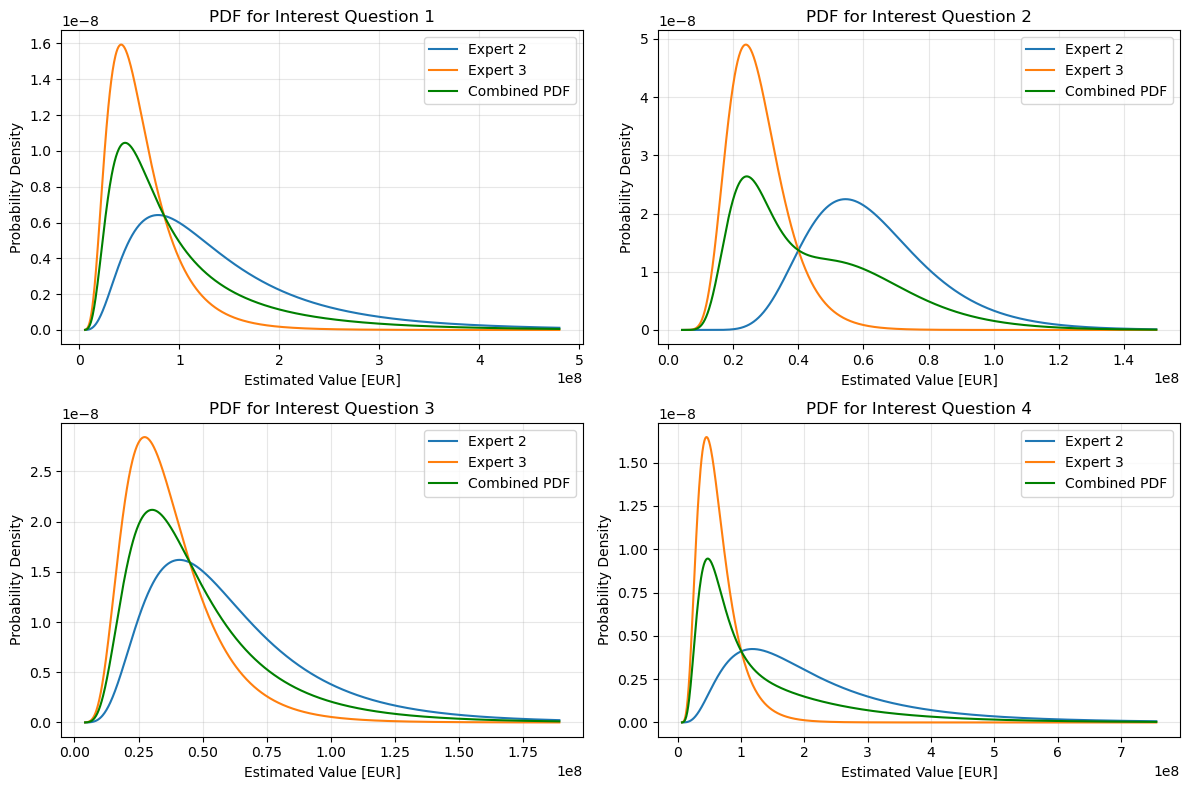

In [23]:
num_questions = len(expert_int[0])
finallst = []

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axslst = [[0,0],[0,1],[1,0],[1,1]]
colors = ['#1f77b4', '#ff7f0e']
Wfinal = [Comb_scores[i]/sum(Comb_scores[1:3]) for i in [1,2]]  #Adjust weights for only experts 2 and 3

for q_idx in range(num_questions):
    all_p5s = [expert_int[1][q_idx][0], expert_int[2][q_idx][0]]
    all_p95s = [expert_int[1][q_idx][2], expert_int[2][q_idx][2]]
    x_min = min(all_p5s) * 0.5
    x_max = max(all_p95s) * 1.5
    x = np.linspace(x_min, x_max, 1000)
    dx = x[1] - x[0]

    pdflst = []
    for e_idx in [1,2]:     #Only for experts 2 and 3
        p5, p50, p95 = expert_int[e_idx][q_idx]
        
        s, scale = fit_lognorm(p5, p50, p95)
        
        pdf = lognorm.pdf(x, s, scale=scale)
        pdflst.append(pdf)
        
        axs[axslst[q_idx][0], axslst[q_idx][1]].plot(x, pdf, label=f'Expert {e_idx + 1}', color=colors[e_idx-1])

    pdffinal = Wfinal[0] * np.array(pdflst[0]) + Wfinal[1] * np.array(pdflst[1])

    #Find mode, 5th and 95th percentiles of the combined distribution
    max_idx = np.argmax(pdffinal)
    mode_emp = x[max_idx]
    
    cdf_emp = np.cumsum(pdffinal) * dx
    cdf_emp = cdf_emp / cdf_emp[-1] 

    p5_emp = np.interp(0.05, cdf_emp, x)
    p95_emp = np.interp(0.95, cdf_emp, x)
    finallst.append((p5_emp, mode_emp, p95_emp))

    axs[axslst[q_idx][0], axslst[q_idx][1]].plot(x, pdffinal, label='Combined PDF', color='green')

    axs[axslst[q_idx][0], axslst[q_idx][1]].set_title(f'PDF for Interest Question {q_idx + 1}')
    axs[axslst[q_idx][0], axslst[q_idx][1]].set_xlabel('Estimated Value [EUR]')
    axs[axslst[q_idx][0], axslst[q_idx][1]].set_ylabel('Probability Density')
    axs[axslst[q_idx][0], axslst[q_idx][1]].legend()
    axs[axslst[q_idx][0], axslst[q_idx][1]].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
for q_idx in range(num_questions):
    print(f'Final estimates for Question {q_idx + 1}:')
    print(f'  5th Percentile: {finallst[q_idx][0]:.4e}')
    print(f'  Mode: {finallst[q_idx][1]:.4e}')
    print(f'  95th Percentile: {finallst[q_idx][2]:.4e}\n')

Final estimates for Question 1:
  5th Percentile: 2.6503e+07
  Mode: 4.5581e+07
  95th Percentile: 2.5355e+08

Final estimates for Question 2:
  5th Percentile: 1.7226e+07
  Mode: 2.4092e+07
  95th Percentile: 8.8017e+07

Final estimates for Question 3:
  5th Percentile: 1.7577e+07
  Mode: 3.0276e+07
  95th Percentile: 1.0359e+08

Final estimates for Question 4:
  5th Percentile: 2.9869e+07
  Mode: 4.7345e+07
  95th Percentile: 3.8417e+08

